# 🩺 Diabetic Retinopathy Detection
## CNN Feature Extraction + Federated Learning (FedAvg)

**Pipeline Overview:**
1. Mount Google Drive & Extract Dataset
2. Explore & Visualize Data
3. Preprocessing & Augmentation
4. CNN Model Architecture (Feature Extractor)
5. Federated Learning with FedAvg (2 Clients)
6. Evaluation & Metrics
7. Prediction on New Images

**Dataset structure expected inside ZIP:**
```
dataset.zip
├── DR/         ← Diabetic Retinopathy images
└── No_DR/      ← Normal (healthy) images
```

---
## 📦 Step 1: Install Dependencies

In [ ]:
!pip install tensorflow matplotlib seaborn scikit-learn numpy pandas Pillow tqdm -q

## 📁 Step 2: Mount Google Drive & Extract Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile

# ✏️ UPDATE THIS PATH to your ZIP file location in Google Drive
ZIP_PATH = '/content/drive/MyDrive/diabetic_retinopathy.zip'   # <-- Change this
EXTRACT_DIR = '/content/dataset'

# Extract ZIP
if not os.path.exists(EXTRACT_DIR):
    print('Extracting dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print('Extraction complete!')
else:
    print('Dataset already extracted.')

# Show folder structure
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:3]:
            print(f'{subindent}{f}')
        if len(files) > 3:
            print(f'{subindent}... and {len(files)-3} more files')

Extracting dataset...
Extraction complete!
dataset/
  diabetic_retinopathy/
    No_DR/
    DR/


In [ ]:
import os

# Auto-detect DR and No_DR folders (handles nested zip extraction)
DR_DIR = None
NO_DR_DIR = None

for root, dirs, files in os.walk(EXTRACT_DIR):
    for d in dirs:
        if d == 'DR':
            DR_DIR = os.path.join(root, d)
        elif d == 'No_DR':
            NO_DR_DIR = os.path.join(root, d)

print(f'DR folder     : {DR_DIR}')
print(f'No_DR folder  : {NO_DR_DIR}')
print(f'DR images     : {len(os.listdir(DR_DIR))}')
print(f'No_DR images  : {len(os.listdir(NO_DR_DIR))}')

DR folder     : /content/dataset/diabetic_retinopathy/DR
No_DR folder  : /content/dataset/diabetic_retinopathy/No_DR
DR images     : 1050
No_DR images  : 1026


## 🔍 Step 3: Explore & Visualize Dataset

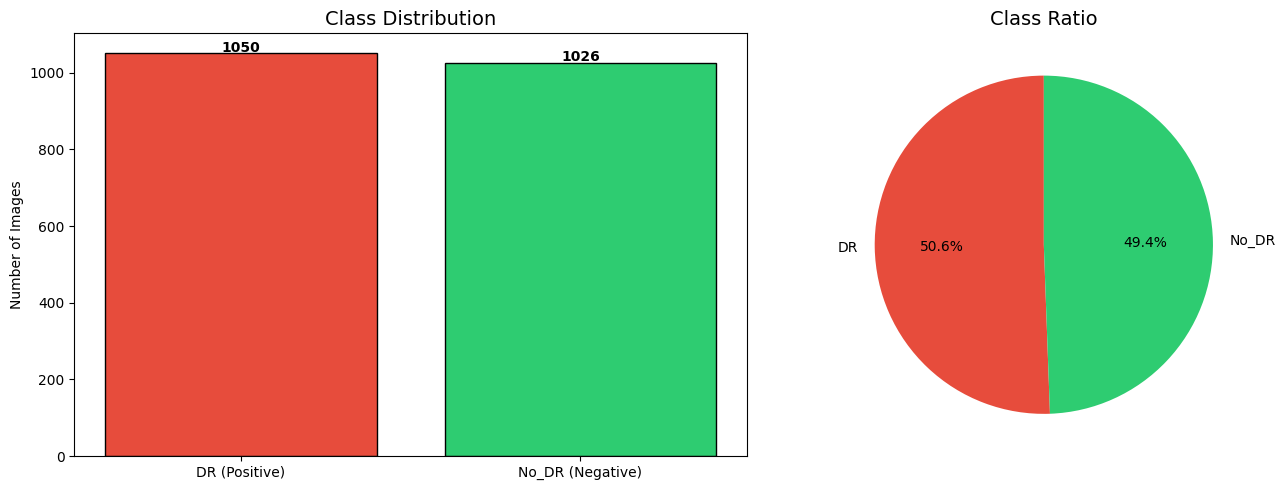

Total images: 2076


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Class distribution
dr_count = len(os.listdir(DR_DIR))
no_dr_count = len(os.listdir(NO_DR_DIR))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(['DR (Positive)', 'No_DR (Negative)'], [dr_count, no_dr_count],
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_ylabel('Number of Images')
for i, v in enumerate([dr_count, no_dr_count]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie([dr_count, no_dr_count], labels=['DR', 'No_DR'],
            colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Ratio', fontsize=14)

plt.tight_layout()
plt.show()
print(f'Total images: {dr_count + no_dr_count}')

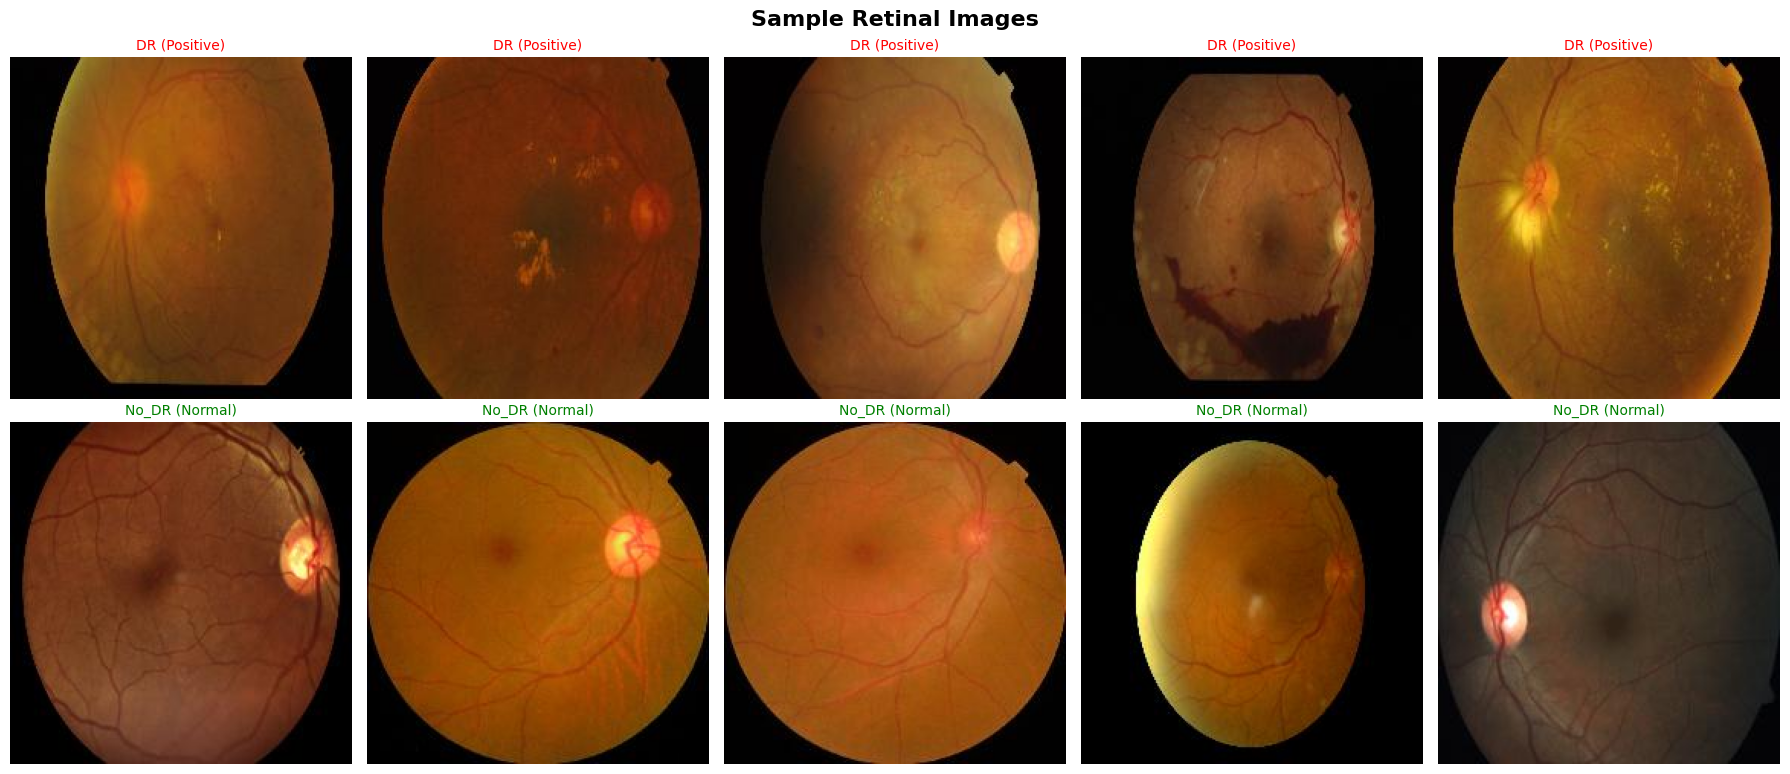

In [ ]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Sample Retinal Images', fontsize=16, fontweight='bold')

dr_images = random.sample(os.listdir(DR_DIR), 5)
no_dr_images = random.sample(os.listdir(NO_DR_DIR), 5)

for i, img_name in enumerate(dr_images):
    img = mpimg.imread(os.path.join(DR_DIR, img_name))
    axes[0, i].imshow(img)
    axes[0, i].set_title('DR (Positive)', color='red', fontsize=10)
    axes[0, i].axis('off')

for i, img_name in enumerate(no_dr_images):
    img = mpimg.imread(os.path.join(NO_DR_DIR, img_name))
    axes[1, i].imshow(img)
    axes[1, i].set_title('No_DR (Normal)', color='green', fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## ⚙️ Step 4: Configuration & Hyperparameters

In [ ]:
# ============================================================
#  GLOBAL CONFIGURATION  (edit here to tune the experiment)
# ============================================================
IMG_SIZE        = (224, 224)    # Input image size
BATCH_SIZE      = 32            # Batch size per client
NUM_CLASSES     = 2             # DR / No_DR
NUM_CLIENTS     = 2             # Federated clients
FL_ROUNDS       = 10            # Federated learning rounds
LOCAL_EPOCHS    = 3             # Local training epochs per round
LEARNING_RATE   = 0.001
TEST_SPLIT      = 0.2           # 20% for global test set
VAL_SPLIT       = 0.1           # 10% for validation
RANDOM_SEED     = 42
CLASS_NAMES     = ['DR', 'No_DR']

print('Configuration loaded successfully!')
print(f'  Image size     : {IMG_SIZE}')
print(f'  FL Rounds      : {FL_ROUNDS}')
print(f'  Clients        : {NUM_CLIENTS}')
print(f'  Local epochs   : {LOCAL_EPOCHS}')

Configuration loaded successfully!
  Image size     : (224, 224)
  FL Rounds      : 10
  Clients        : 2
  Local epochs   : 3


## 🛠️ Step 5: Data Preprocessing & Train/Test Split

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

def load_images_from_folder(folder, label, img_size):
    """Load all images from a folder and assign a label."""
    images, labels = [], []
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    files = [f for f in os.listdir(folder) if f.lower().endswith(valid_exts)]
    for fname in tqdm(files, desc=f'Loading {os.path.basename(folder)}'):
        try:
            img = Image.open(os.path.join(folder, fname)).convert('RGB')
            img = img.resize(img_size)
            images.append(np.array(img, dtype=np.float32) / 255.0)
            labels.append(label)
        except Exception as e:
            print(f'Skipping {fname}: {e}')
    return images, labels

# Load both classes
dr_images, dr_labels       = load_images_from_folder(DR_DIR, 0, IMG_SIZE)      # DR=0
no_dr_images, no_dr_labels = load_images_from_folder(NO_DR_DIR, 1, IMG_SIZE)   # No_DR=1

# Combine and convert
X = np.array(dr_images + no_dr_images, dtype=np.float32)
y = np.array(dr_labels + no_dr_labels, dtype=np.int32)

print(f'\nDataset loaded:')
print(f'  X shape: {X.shape}')
print(f'  y shape: {y.shape}')
print(f'  DR samples    : {np.sum(y == 0)}')
print(f'  No_DR samples : {np.sum(y == 1)}')

Loading No_DR: 100%|██████████| 1026/1026 [00:01<00:00, 974.06it/s]



Dataset loaded:
  X shape: (2076, 224, 224, 3)
  y shape: (2076,)
  DR samples    : 1050
  No_DR samples : 1026


In [ ]:
from sklearn.model_selection import train_test_split

# Global train/test split (test set held out from FL entirely)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=RANDOM_SEED, stratify=y
)

# Validation split from training data
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    random_state=RANDOM_SEED, stratify=y_train_full
)

print(f'Train    : {X_train.shape[0]} samples')
print(f'Val      : {X_val.shape[0]} samples')
print(f'Test     : {X_test.shape[0]} samples')

Train    : 1452 samples
Val      : 208 samples
Test     : 416 samples


## 🔀 Step 6: Split Data Among Federated Clients

In [ ]:
def split_data_for_clients(X, y, num_clients, seed=42):
    """
    Splits training data equally among clients (IID split).
    Each client gets a stratified subset of the data.
    """
    np.random.seed(seed)
    indices = np.random.permutation(len(X))
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    client_data = []
    chunk_size = len(X) // num_clients
    for i in range(num_clients):
        start = i * chunk_size
        end   = start + chunk_size if i < num_clients - 1 else len(X)
        client_data.append((
            X_shuffled[start:end],
            y_shuffled[start:end]
        ))
    return client_data

client_datasets = split_data_for_clients(X_train, y_train, NUM_CLIENTS)

for i, (cx, cy) in enumerate(client_datasets):
    print(f'Client {i+1}: {cx.shape[0]} samples | DR={np.sum(cy==0)} | No_DR={np.sum(cy==1)}')

Client 1: 726 samples | DR=373 | No_DR=353
Client 2: 726 samples | DR=362 | No_DR=364


## 🧠 Step 7: CNN Model Architecture (Feature Extractor)

In [ ]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2

def build_cnn_model(input_shape=(224, 224, 3), num_classes=2, learning_rate=0.001):
    """
    CNN Model using MobileNetV2 as the feature extractor backbone.
    - Pretrained on ImageNet (transfer learning)
    - Top layers frozen for feature extraction
    - Custom classification head on top
    """
    # ── Feature Extractor (Backbone) ──
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,       # Remove ImageNet head
        weights='imagenet'       # Pretrained weights
    )
    base_model.trainable = False  # Freeze backbone (feature extraction mode)

    # ── Classification Head ──
    inputs  = tf.keras.Input(shape=input_shape)
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)         # Aggregate features
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu',
                            kernel_regularizer=regularizers.l2(1e-4))(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation='relu',
                            kernel_regularizer=regularizers.l2(1e-4))(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)  # Binary output

    model = models.Model(inputs, outputs, name='DR_CNN_FedAvg')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build and display global model
global_model = build_cnn_model(
    input_shape=IMG_SIZE + (3,),
    num_classes=NUM_CLASSES,
    learning_rate=LEARNING_RATE
)
global_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DR_CNN_FedAvg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,194 (10.01 MB)

 Trainable params: 363,650 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 🌐 Step 8: Federated Learning — FedAvg Algorithm

**FedAvg (Federated Averaging)** works as follows:
1. The **server** distributes the global model to all clients
2. Each **client** trains locally on its private data
3. Clients send their **model weights** back to the server
4. The server **averages** the weights (weighted by dataset size)
5. Repeat for N rounds

In [ ]:
import copy

# ─────────────────────────────────────────
#  FedAvg Core Functions
# ─────────────────────────────────────────

def get_model_weights(model):
    """Extract weights from a model."""
    return model.get_weights()

def set_model_weights(model, weights):
    """Apply weights to a model."""
    model.set_weights(weights)

def fedavg_aggregate(client_weights_list, client_sizes):
    """
    FedAvg: Weighted average of client model weights.
    Weight proportional to each client's dataset size.
    """
    total_samples = sum(client_sizes)
    avg_weights = []

    for layer_idx in range(len(client_weights_list[0])):
        layer_avg = np.zeros_like(client_weights_list[0][layer_idx])
        for client_idx, weights in enumerate(client_weights_list):
            fraction = client_sizes[client_idx] / total_samples
            layer_avg += fraction * weights[layer_idx]
        avg_weights.append(layer_avg)

    return avg_weights

def client_update(global_weights, client_X, client_y,
                  local_epochs, batch_size, learning_rate):
    """
    Local client training:
    1. Load global weights into local model
    2. Train on local data
    3. Return updated weights + local metrics
    """
    # Build a fresh local model
    local_model = build_cnn_model(
        input_shape=IMG_SIZE + (3,),
        num_classes=NUM_CLASSES,
        learning_rate=learning_rate
    )
    # Initialize with global weights
    set_model_weights(local_model, global_weights)

    # Data augmentation for local training
    datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1
    )

    # Local training
    history = local_model.fit(
        datagen.flow(client_X, client_y, batch_size=batch_size),
        epochs=local_epochs,
        verbose=0
    )

    return get_model_weights(local_model), history

print('FedAvg functions defined successfully!')

FedAvg functions defined successfully!


In [ ]:
# ─────────────────────────────────────────
#  Federated Learning Training Loop
# ─────────────────────────────────────────

print('=' * 60)
print('   FEDERATED LEARNING — FedAvg Algorithm')
print(f'   Clients: {NUM_CLIENTS} | Rounds: {FL_ROUNDS} | Local Epochs: {LOCAL_EPOCHS}')
print('=' * 60)

# Tracking metrics across rounds
fl_history = {
    'round': [],
    'val_accuracy': [],
    'val_loss': [],
    'client_losses': [[] for _ in range(NUM_CLIENTS)]
}

# Initial global weights
global_weights = get_model_weights(global_model)

best_val_acc  = 0.0
best_weights  = None

for fl_round in range(1, FL_ROUNDS + 1):
    print(f'\n🔄 Round {fl_round}/{FL_ROUNDS}')
    print('-' * 40)

    client_weights_list = []
    client_sizes        = []

    # ── Client Training Phase ──
    for client_id in range(NUM_CLIENTS):
        client_X, client_y = client_datasets[client_id]
        print(f'  📱 Client {client_id + 1} training on {len(client_X)} samples...', end=' ')

        updated_weights, local_history = client_update(
            global_weights=global_weights,
            client_X=client_X,
            client_y=client_y,
            local_epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            learning_rate=LEARNING_RATE
        )

        client_weights_list.append(updated_weights)
        client_sizes.append(len(client_X))

        local_loss = np.mean(local_history.history['loss'])
        local_acc  = np.mean(local_history.history['accuracy'])
        fl_history['client_losses'][client_id].append(local_loss)
        print(f'Loss={local_loss:.4f} | Acc={local_acc:.4f}')

    # ── FedAvg Aggregation ──
    print('  🔗 Aggregating weights (FedAvg)...')
    global_weights = fedavg_aggregate(client_weights_list, client_sizes)
    set_model_weights(global_model, global_weights)

    # ── Global Validation ──
    val_loss, val_acc = global_model.evaluate(X_val, y_val, verbose=0)
    fl_history['round'].append(fl_round)
    fl_history['val_accuracy'].append(val_acc)
    fl_history['val_loss'].append(val_loss)

    print(f'  ✅ Global Model — Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        best_weights  = global_weights
        print(f'  ⭐ New best model saved! (Val Acc: {best_val_acc:.4f})')

print('\n' + '=' * 60)
print(f'   Federated Learning Complete!')
print(f'   Best Validation Accuracy: {best_val_acc:.4f}')
print('=' * 60)

# Restore best weights
set_model_weights(global_model, best_weights)

   FEDERATED LEARNING — FedAvg Algorithm
   Clients: 2 | Rounds: 10 | Local Epochs: 3

🔄 Round 1/10
----------------------------------------
  📱 Client 1 training on 726 samples... Loss=0.3408 | Acc=0.9054
  📱 Client 2 training on 726 samples... Loss=0.3278 | Acc=0.9063
  🔗 Aggregating weights (FedAvg)...
  ✅ Global Model — Val Loss: 0.3523 | Val Acc: 0.8798
  ⭐ New best model saved! (Val Acc: 0.8798)

🔄 Round 2/10
----------------------------------------
  📱 Client 1 training on 726 samples... Loss=0.2828 | Acc=0.9307
  📱 Client 2 training on 726 samples... Loss=0.2456 | Acc=0.9380
  🔗 Aggregating weights (FedAvg)...
  ✅ Global Model — Val Loss: 0.2072 | Val Acc: 0.9712
  ⭐ New best model saved! (Val Acc: 0.9712)

🔄 Round 3/10
----------------------------------------
  📱 Client 1 training on 726 samples... Loss=0.2247 | Acc=0.9509
  📱 Client 2 training on 726 samples... Loss=0.1975 | Acc=0.9550
  🔗 Aggregating weights (FedAvg)...
  ✅ Global Model — Val Loss: 0.1618 | Val Acc: 0.9808
 

## 📊 Step 9: Visualize Training Progress

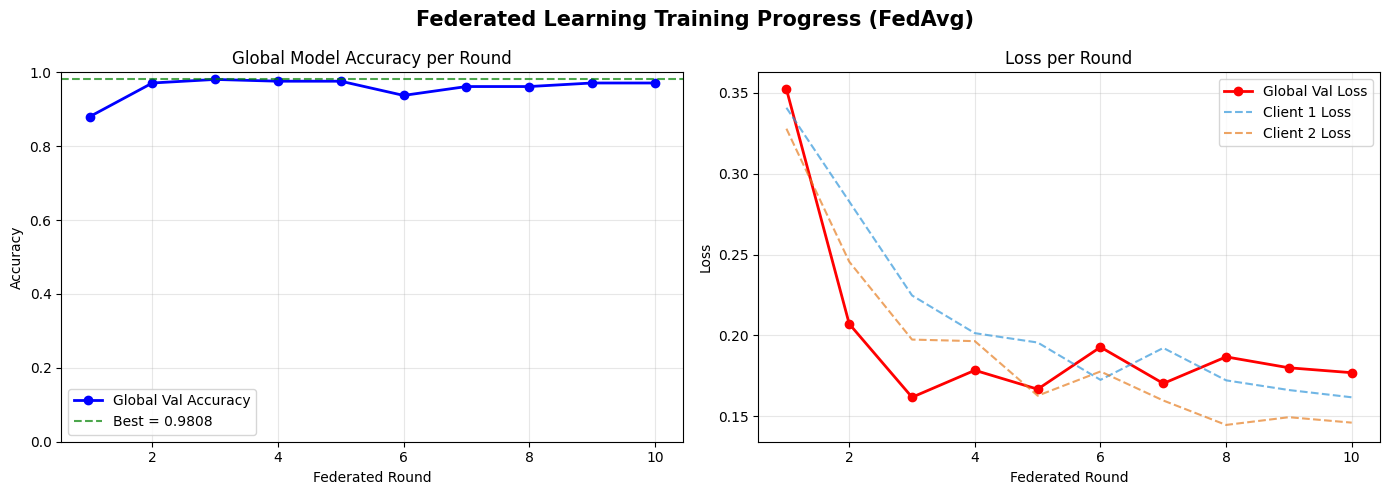

Plot saved to /content/fl_training_progress.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Federated Learning Training Progress (FedAvg)', fontsize=15, fontweight='bold')

rounds = fl_history['round']

# Accuracy
axes[0].plot(rounds, fl_history['val_accuracy'], 'b-o', linewidth=2, markersize=6, label='Global Val Accuracy')
axes[0].axhline(y=best_val_acc, color='green', linestyle='--', alpha=0.7, label=f'Best = {best_val_acc:.4f}')
axes[0].set_title('Global Model Accuracy per Round')
axes[0].set_xlabel('Federated Round')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(rounds, fl_history['val_loss'], 'r-o', linewidth=2, markersize=6, label='Global Val Loss')
# Client losses
colors = ['#3498db', '#e67e22']
for i in range(NUM_CLIENTS):
    axes[1].plot(rounds, fl_history['client_losses'][i],
                 linestyle='--', alpha=0.7, color=colors[i], label=f'Client {i+1} Loss')
axes[1].set_title('Loss per Round')
axes[1].set_xlabel('Federated Round')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/fl_training_progress.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to /content/fl_training_progress.png')

## 📈 Step 10: Final Evaluation on Test Set

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
import seaborn as sns

# Predictions
y_pred_prob = global_model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

# Metrics
test_loss, test_acc = global_model.evaluate(X_test, y_test, verbose=0)
auc_score = roc_auc_score(y_test, y_pred_prob[:, 1])

print('=' * 50)
print('   FINAL TEST SET RESULTS')
print('=' * 50)
print(f'  Test Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  Test Loss      : {test_loss:.4f}')
print(f'  ROC-AUC Score  : {auc_score:.4f}')
print('=' * 50)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

   FINAL TEST SET RESULTS
  Test Accuracy  : 0.9615 (96.15%)
  Test Loss      : 0.1932
  ROC-AUC Score  : 0.9860

Classification Report:
              precision    recall  f1-score   support

          DR       0.98      0.94      0.96       210
       No_DR       0.94      0.99      0.96       206

    accuracy                           0.96       416
   macro avg       0.96      0.96      0.96       416
weighted avg       0.96      0.96      0.96       416



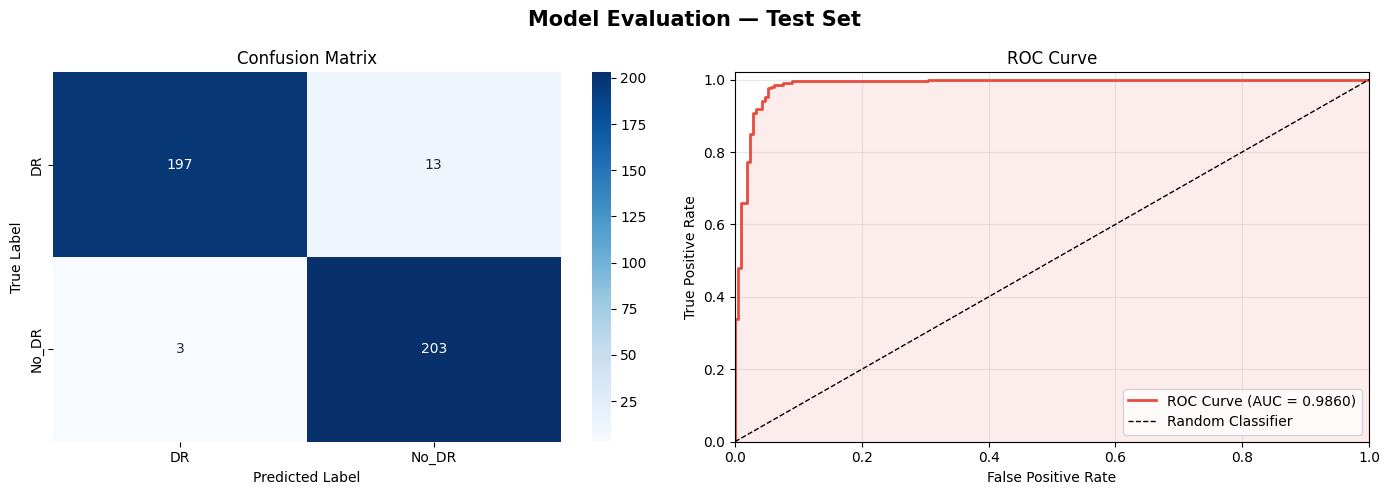

Evaluation plots saved to /content/evaluation_results.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation — Test Set', fontsize=15, fontweight='bold')

# ── Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ── ROC Curve ──
fpr, tpr, _ = roc_curve(y_test, y_pred_prob[:, 1])
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC Curve (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Evaluation plots saved to /content/evaluation_results.png')

## 🔬 Step 11: Visualize Predictions on Sample Test Images

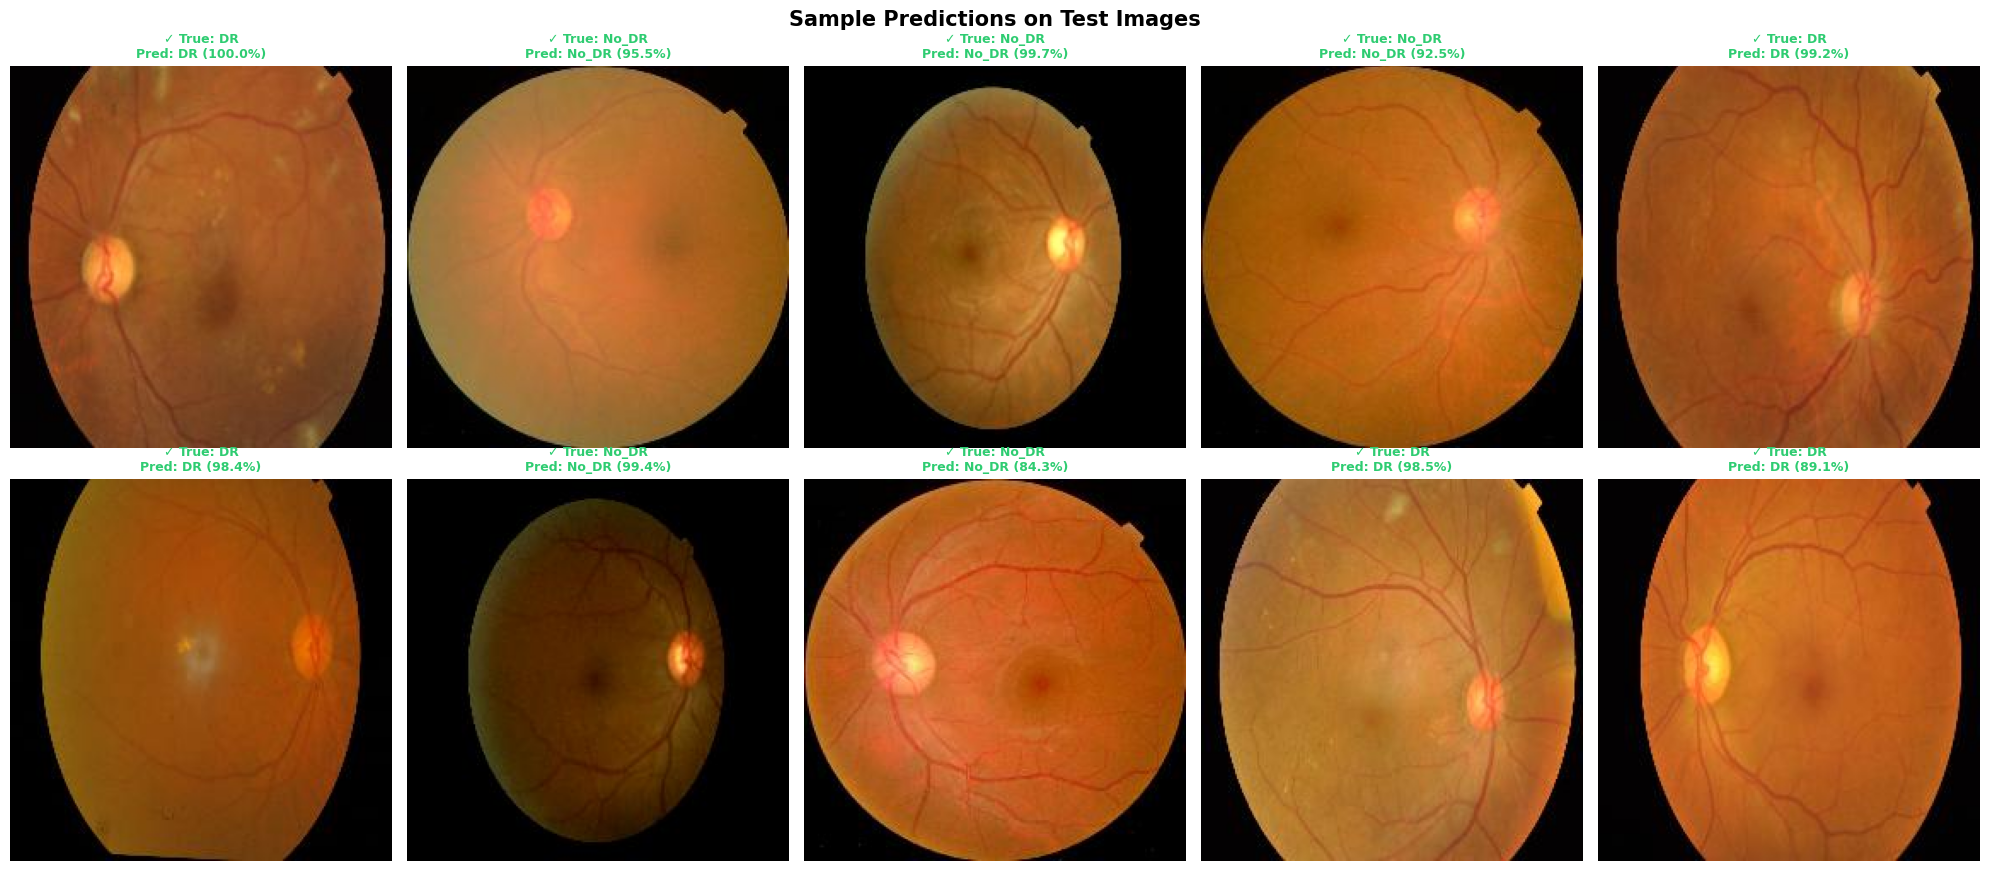

In [ ]:
# Show 10 random test predictions
sample_indices = np.random.choice(len(X_test), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle('Sample Predictions on Test Images', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    img        = X_test[idx]
    true_label = CLASS_NAMES[y_test[idx]]
    pred_label = CLASS_NAMES[y_pred[idx]]
    confidence = y_pred_prob[idx][y_pred[idx]] * 100
    correct    = true_label == pred_label

    axes[i].imshow(img)
    color = '#2ecc71' if correct else '#e74c3c'
    marker = '✓' if correct else '✗'
    axes[i].set_title(
        f'{marker} True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)',
        color=color, fontsize=9, fontweight='bold'
    )
    axes[i].axis('off')
    # Add colored border
    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_linewidth(3)

plt.tight_layout()
plt.savefig('/content/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 Step 12: Save the Global Model

In [ ]:
# Save in HDF5 format (recommended for Keras)
MODEL_SAVE_PATH = '/content/drive/MyDrive/dr_fedavg_model.h5'

global_model.save(MODEL_SAVE_PATH)
print(f'Model saved to Google Drive: {MODEL_SAVE_PATH}')

# Also save locally
global_model.save('/content/dr_fedavg_model.h5')
print('Model also saved locally: /content/dr_fedavg_model.h5')

Model saved to Google Drive: /content/drive/MyDrive/dr_fedavg_model.h5
Model also saved locally: /content/dr_fedavg_model.h5


## 🔮 Step 13: Predict on a New Custom Image

In [ ]:
def predict_single_image(model, image_path, img_size=(224, 224)):
    """
    Predict DR/No_DR for a single retinal image.
    Args:
        model      : Trained global model
        image_path : Path to the image file
        img_size   : Expected input size
    Returns:
        Prediction label, confidence, probabilities
    """
    # Load and preprocess
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize(img_size)
    img_array = np.array(img_resized, dtype=np.float32) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Predict
    probs = model.predict(img_batch, verbose=0)[0]
    pred_idx   = np.argmax(probs)
    pred_label = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx] * 100

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(img)
    color = '#e74c3c' if pred_label == 'DR' else '#2ecc71'
    axes[0].set_title(f'Prediction: {pred_label}\nConfidence: {confidence:.2f}%',
                      fontsize=14, fontweight='bold', color=color)
    axes[0].axis('off')

    bars = axes[1].barh(CLASS_NAMES, probs * 100,
                        color=['#e74c3c', '#2ecc71'], edgecolor='black')
    axes[1].set_xlim([0, 100])
    axes[1].set_xlabel('Probability (%)')
    axes[1].set_title('Class Probabilities')
    for bar, prob in zip(bars, probs):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{prob*100:.2f}%', va='center', fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return pred_label, confidence, probs

print('predict_single_image() function ready!')
print('\nUsage:')
print('  label, conf, probs = predict_single_image(global_model, "/path/to/image.jpg")')

predict_single_image() function ready!

Usage:
  label, conf, probs = predict_single_image(global_model, "/path/to/image.jpg")


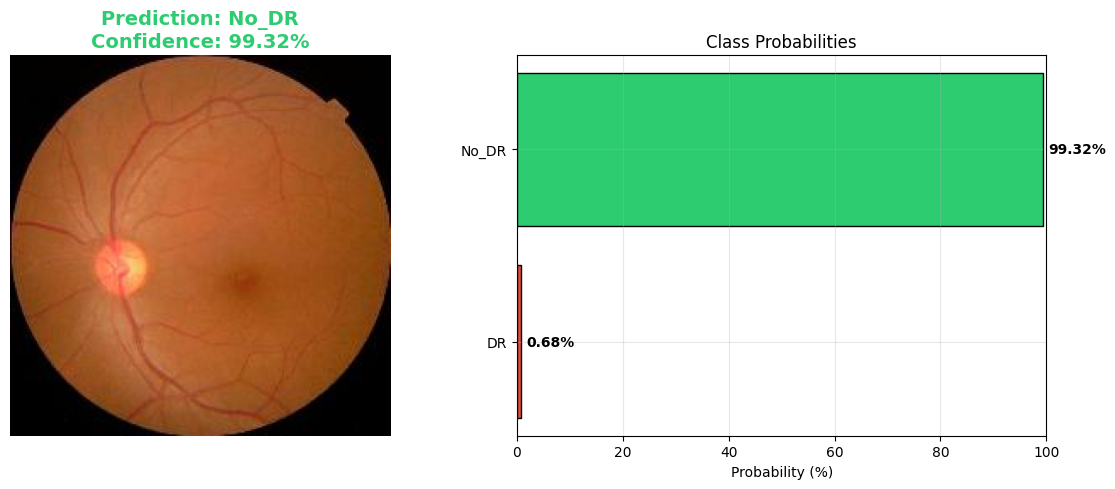


🩺 Diagnosis : No_DR
   Confidence : 99.32%
   DR prob    : 0.68%
   No_DR prob : 99.32%


In [ ]:
# ✏️ UPDATE with your image path to test
TEST_IMAGE_PATH = '/content/dataset/diabetic_retinopathy/No_DR/002c21358ce6_png.rf.31ccb999f6cc5cec5b0582cc29aac015.jpg'   # <-- Change this

if os.path.exists(TEST_IMAGE_PATH):
    label, confidence, probs = predict_single_image(global_model, TEST_IMAGE_PATH)
    print(f'\n🩺 Diagnosis : {label}')
    print(f'   Confidence : {confidence:.2f}%')
    print(f'   DR prob    : {probs[0]*100:.2f}%')
    print(f'   No_DR prob : {probs[1]*100:.2f}%')
else:
    print(f'⚠️  Image not found: {TEST_IMAGE_PATH}')
    print('Please update TEST_IMAGE_PATH with a valid image path.')
    # Demo: predict on a random test image
    print('\n--- Demo on a random test image ---')
    demo_idx = np.random.randint(0, len(X_test))
    demo_img = X_test[demo_idx]
    true_lbl = CLASS_NAMES[y_test[demo_idx]]
    probs_demo = global_model.predict(np.expand_dims(demo_img, 0), verbose=0)[0]
    pred_demo = CLASS_NAMES[np.argmax(probs_demo)]
    plt.figure(figsize=(5, 5))
    plt.imshow(demo_img)
    plt.title(f'True: {true_lbl} | Pred: {pred_demo} ({np.max(probs_demo)*100:.1f}%)',
              fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

## 📋 Step 14: Load Saved Model & Predict (Inference Only)

In [ ]:
# Load model from Drive for future inference (run this cell independently)
from tensorflow.keras.models import load_model

MODEL_PATH  = '/content/drive/MyDrive/dr_fedavg_model.h5'
loaded_model = load_model(MODEL_PATH)
print(f'Model loaded from: {MODEL_PATH}')

# Quick sanity check
test_loss, test_acc = loaded_model.evaluate(X_test, y_test, verbose=0)
print(f'Loaded Model — Test Accuracy: {test_acc:.4f}')

Model loaded from: /content/drive/MyDrive/dr_fedavg_model.h5
Loaded Model — Test Accuracy: 0.9615


---
## ✅ Project Summary

| Component | Details |
|---|---|
| **Task** | Binary Classification: DR vs No_DR |
| **Feature Extractor** | MobileNetV2 (pretrained on ImageNet) |
| **FL Algorithm** | FedAvg (Federated Averaging) |
| **Clients** | 2 simulated clients (IID split) |
| **FL Rounds** | 10 |
| **Local Epochs** | 3 per round |
| **Input Size** | 224×224×3 |
| **Privacy** | Raw images never leave client — only weights shared |

### Key Concepts:
- **FedAvg** aggregates model weights proportionally to dataset size — no raw data is ever shared
- **MobileNetV2** as backbone provides powerful pre-learned visual features
- **Transfer learning** reduces training time significantly
- **Data augmentation** applied locally at each client for better generalization
